In [ ]:
#Question 1a
import requests 
from bs4 import BeautifulSoup
import re
assignment_url = 'https://sitescrape.awh.durham.ac.uk/COMP42315/publicationfull_year_characteranimation.htm'
response = requests.get(assignment_url, verify=False)
if response.status_code != 200: #incase of an unsuccessful request. 200 ok status code = successful request
    print('Failed to retrieve page')
else:
    soup = BeautifulSoup(response.text, 'html.parser')
    publication_links = []
    all_publications = soup.find_all('div', class_ = 'w3-cell-middle')
    class_location = soup.find('div', class_ = 'w3-cell-middle')
    main_site = 'https://sitescrape.awh.durham.ac.uk/COMP42315/'
    for class_location in all_publications:
        publication_link = class_location.find('a', class_ = 'LinkButton')
        url = publication_link.get('href')
        full_link = main_site + url
        publication_links.append(full_link)

        publication_titles = []
        publication_years = []
        publication_venues = []
        publication_authors = []
        impact_factors = []
        citations = []

        for i in publication_links:
            linkedresponse = requests.get(i, verify = False)
            pagesoup = BeautifulSoup(linkedresponse.text, 'html.parser')
            publication_title = pagesoup.find('h1').text.strip()
            publication_titles.append(publication_title)
            
        
            pub_header = pagesoup.find('h2', string = 'Publication')
            if pub_header:
                pub_div = pub_header.find_next_sibling('div')
                summary = pub_div.get_text()
                year_match = re.search(r'\d{4}', summary) #searches for a sequence of 4 digits to extract the year from the summary
                if year_match:
                    publication_years.append(year_match.group())
                else:
                    publication_years.append('N/A')
            

                br_tag = pub_div.find('br')
                if br_tag:
                    publication_venue = br_tag.next_sibling.strip()
                else:
                    print('N/A')
                if publication_venue:
                    publication_venues.append(publication_venue)
                else:
                    publication_venues.append('N/A')

                
                if ' by ' in summary and ' in ' in summary: #spaces within quotation marks to ensure that only the words are excluded and not letters that are parts of names
                    after = summary.split(' by ')[-1] 
                    before = after.split(' in ')[0].strip()
                    raw_authors = before.replace('and', ',')
                    authors = [name.strip() for name in raw_authors.split(',')]
                    publication_authors.append(authors)
                else:
                    print('N/A')

                stats = pub_div.get_text()
                citation = re.search(r'Citation:\s*(\d+)', stats) #searches for citation and the spaces and digits following it
                if citation:
                    citations.append(int(citation.group(1))) #returns the match
                else:
                    citations.append(0)
                
                impact_factor = re.search(r'Impact Factor:\s*([\d.]+)', stats)
                if impact_factor:
                    impact_factors.append(float(impact_factor.group(1)))
                else:
                    impact_factors.append(0)


print(f"Publication Titles: {publication_titles}")
print(f"Publication Years: {publication_years}")
print(f"Publication Venues: {publication_venues}")
print(f"Publication Authors: {publication_authors}")
print(f"Impact Factors: {impact_factors}")
print(f"Citations: {citations}")

/opt/anaconda3/lib/python3.13/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'sitescrape.awh.durham.ac.uk'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'sitescrape.awh.durham.ac.uk'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'sitescrape.awh.durham.ac.uk'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/opt/anaconda3/lib/

Publication Titles: ['Spatio-temporal Manifold Learning for Human Motions via Long-horizon Modeling', 'A Quadruple Diffusion Convolutional Recurrent Network for Human Motion Prediction', 'GAN-based Reactive Motion Synthesis with Class-aware Discriminators for Human-human Interaction', 'Automatic Sign Dance Synthesis from Gesture-based Sign Language', 'A Generic Framework for Editing and Synthesizing Multimodal Data with Relative Emotion Strength', 'DanceDJ: A 3D Dance Animation Authoring System for Live Performance', 'Synthesizing Motion with Relative Emotion Strength', 'Depth Sensor based Facial and Body Animation Control', 'Automatic Dance Generation System Considering Sign Language Information', 'Multi-layer Lattice Model for Real-Time Dynamic Character Deformation', 'Human Motion Variation Synthesis with Multivariate Gaussian Processes', 'Topology Aware Data-Driven Inverse Kinematics', 'Preparation Behaviour Synthesis with Reinforcement Learning', 'Real-time Physical Modelling of C

/opt/anaconda3/lib/python3.13/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'sitescrape.awh.durham.ac.uk'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


In [ ]:
#Question 1b
import pandas as pd
import openpyxl

keys = ['Publication Title', 'Publication Year', 'Publication Venue', 'Publication Authors', 'Citations', 'Impact Factors']
publication_info = {key: [] for key in keys}
for i in publication_titles:
    publication_info['Publication Title'].append(i)
for i in publication_years:
    publication_info['Publication Year'].append(i)
for i in publication_venues:
    publication_info['Publication Venue'].append(i)
for i in publication_authors:
    publication_info['Publication Authors'].append(i)
for i in citations:
    publication_info['Citations'].append(i)
for i in impact_factors:
    publication_info['Impact Factors'].append(i)

information = pd.DataFrame(publication_info)
information.to_excel('PublicationInfo.xlsx')

In [63]:
#Question 1c
sortedyear = information.sort_values(by='Publication Year',ascending=False)
sortedyear.index = sortedyear.index +1 #I wanted the index to start at 1 not 0
sortedyear #index is based on year as that is the order the publications are listed by on the webpage where I scraped each publication link

,Publication Title,Publication Year,Publication Venue,Publication Authors,Citations,Impact Factors
1,Spatio-temporal Manifold Learning for Human Mo...,2023,IEEE Transactions on Visualization and Compute...,"[Manli Zhu, Qianhui Men, Hubert P. H. Shum, Ed...",48,4.579
2,A Quadruple Diffusion Convolutional Recurrent ...,2022,IEEE Transactions on Circuits and Systems for ...,"[Stephen Clark, Hubert P. H. Shum, Merryn D. C...",228,4.685
3,GAN-based Reactive Motion Synthesis with Class...,2022,Computers and Graphics (C&G),"[Qianhui Men, Edmond S. L. Ho, Hubert P. H. Sh...",21,1.936
4,Automatic Sign Dance Synthesis from Gesture-ba...,2021,Proceedings of the 2019 International Conferen...,"[Pengpeng Hu, Edmond S. L. Ho, Nauman Aslam, T...",3,0.000
5,A Generic Framework for Editing and Synthesizi...,2019,Computer Animation and Virtual Worlds (CAVW),"[Hubert P. H. Shum, Edmond S. L. Ho, Marie-Pau...",9,1.020
6,DanceDJ: A 3D Dance Animation Authoring System...,2019,Proceedings of the 2017 International Conferen...,"[Muhammad Zeeshan Baig, Nauman Aslam, Hubert P...",41,0.000
7,Synthesizing Motion with Relative Emotion Stre...,2017,Proceedings of the 2017 ACM SIGGRAPH Asia Work...,"[Yijun Shen, He Wang, Edmond S. L. Ho, Longzhi...",3,0.000
8,Depth Sensor based Facial and Body Animation C...,2017,Handbook of Human Motion,"[Yang Yang, Huiwen Bian, Hubert P. H. Shum, Na...",1,0.000
9,Automatic Dance Generation System Considering ...,2016,Proceedings of the 2016 ACM SIGGRAPH (SIGGRAPH...,"[Jie Li, Hubert P. H. Shum, Xin Fu, Graham Sex...",21,0.000
10,Multi-layer Lattice Model for Real-Time Dynami...,2016,Computer Graphics Forum (CGF) - Proceedings of...,"[Jie Li, Yanpeng Qu, Hubert P. H. Shum, Longzh...",44,2.078


In [64]:
information['items'] = information['Publication Authors'].str.len()
sortedauthors = information.sort_values(by='items', ascending=False) 
sortedauthors.index = sortedauthors.index +1
sortedauthors

,Publication Title,Publication Year,Publication Venue,Publication Authors,Citations,Impact Factors,items
5,A Generic Framework for Editing and Synthesizi...,2019,Computer Animation and Virtual Worlds (CAVW),"[Hubert P. H. Shum, Edmond S. L. Ho, Marie-Pau...",9,1.020,6
1,Spatio-temporal Manifold Learning for Human Mo...,2023,IEEE Transactions on Visualization and Compute...,"[Manli Zhu, Qianhui Men, Hubert P. H. Shum, Ed...",48,4.579,5
4,Automatic Sign Dance Synthesis from Gesture-ba...,2021,Proceedings of the 2019 International Conferen...,"[Pengpeng Hu, Edmond S. L. Ho, Nauman Aslam, T...",3,0.000,5
7,Synthesizing Motion with Relative Emotion Stre...,2017,Proceedings of the 2017 ACM SIGGRAPH Asia Work...,"[Yijun Shen, He Wang, Edmond S. L. Ho, Longzhi...",3,0.000,5
8,Depth Sensor based Facial and Body Animation C...,2017,Handbook of Human Motion,"[Yang Yang, Huiwen Bian, Hubert P. H. Shum, Na...",1,0.000,5
9,Automatic Dance Generation System Considering ...,2016,Proceedings of the 2016 ACM SIGGRAPH (SIGGRAPH...,"[Jie Li, Hubert P. H. Shum, Xin Fu, Graham Sex...",21,0.000,5
11,Human Motion Variation Synthesis with Multivar...,2014,Computer Animation and Virtual Worlds (CAVW) -...,"[Yijun Shen, Jingtian Zhang, Longzhi Yang, Hub...",12,1.020,4
21,Simulating Competitive Interactions using Sing...,2009,Proceedings of the 2007 ACM Symposium on Virtu...,"[Hubert P. H. Shum, Taku Komura, Masashi Shira...",112,0.000,4
16,Simulating Multiple Character Interactions wit...,2013,IEEE Transactions on Visualization and Compute...,"[Edmond S. L. Ho, Hubert P. H. Shum, Yiu-ming ...",112,4.579,4
15,Natural Preparation Behavior Synthesis,2013,Computer Animation and Virtual Worlds (CAVW),"[Liuyang Zhou, Lifeng Shang, Hubert P. H. Shum...",1,1.020,4


In [65]:
sortedtitles = information.sort_values(by = 'Publication Title', ascending=True)
sortedtitles.index = sortedtitles.index +1
sortedtitles

,Publication Title,Publication Year,Publication Venue,Publication Authors,Citations,Impact Factors,items
5,A Generic Framework for Editing and Synthesizi...,2019,Computer Animation and Virtual Worlds (CAVW),"[Hubert P. H. Shum, Edmond S. L. Ho, Marie-Pau...",9,1.020,6
2,A Quadruple Diffusion Convolutional Recurrent ...,2022,IEEE Transactions on Circuits and Systems for ...,"[Stephen Clark, Hubert P. H. Shum, Merryn D. C...",228,4.685,3
19,Angular Momentum Guided Motion Concatenation,2011,Computer Animation and Virtual Worlds (CAVW) -...,"[Kevin Mackay, Hubert P. H. Shum, Taku Komura]",36,1.020,3
9,Automatic Dance Generation System Considering ...,2016,Proceedings of the 2016 ACM SIGGRAPH (SIGGRAPH...,"[Jie Li, Hubert P. H. Shum, Xin Fu, Graham Sex...",21,0.000,5
4,Automatic Sign Dance Synthesis from Gesture-ba...,2021,Proceedings of the 2019 International Conferen...,"[Pengpeng Hu, Edmond S. L. Ho, Nauman Aslam, T...",3,0.000,5
6,DanceDJ: A 3D Dance Animation Authoring System...,2019,Proceedings of the 2017 International Conferen...,"[Muhammad Zeeshan Baig, Nauman Aslam, Hubert P...",41,0.000,4
8,Depth Sensor based Facial and Body Animation C...,2017,Handbook of Human Motion,"[Yang Yang, Huiwen Bian, Hubert P. H. Shum, Na...",1,0.000,5
3,GAN-based Reactive Motion Synthesis with Class...,2022,Computers and Graphics (C&G),"[Qianhui Men, Edmond S. L. Ho, Hubert P. H. Sh...",21,1.936,4
24,Generating Realistic Fighting Scenes by Game Tree,2006,Proceedings of the 2006 ACM SIGGRAPH/Eurograph...,"[Hubert P. H. Shum, Taku Komura, Shuntaro Yama...",31,0.000,3
11,Human Motion Variation Synthesis with Multivar...,2014,Computer Animation and Virtual Worlds (CAVW) -...,"[Yijun Shen, Jingtian Zhang, Longzhi Yang, Hub...",12,1.020,4


In [66]:
sortedfactors = information.sort_values(by = 'Impact Factors', ascending= False)
sortedfactors.index = sortedfactors
sortedfactors

,Publication Title,Publication Year,Publication Venue,Publication Authors,Citations,Impact Factors,items
"(Interaction Patches for Multi-Character Animation, 2010, ACM Transactions on Graphics (TOG) - Proceedings of the 2008 ACM SIGGRAPH Asia (SIGGRAPH Asia), [Hubert P. H. Shum, Taku Komura, Shu Takagi], 201, 5.414, 3)",Interaction Patches for Multi-Character Animation,2010,ACM Transactions on Graphics (TOG) - Proceedin...,"[Hubert P. H. Shum, Taku Komura, Shu Takagi]",201,5.414,3
"(A Quadruple Diffusion Convolutional Recurrent Network for Human Motion Prediction, 2022, IEEE Transactions on Circuits and Systems for Video Technology (TCSVT), [Stephen Clark, Hubert P. H. Shum, Merryn D. Constable], 228, 4.685, 3)",A Quadruple Diffusion Convolutional Recurrent ...,2022,IEEE Transactions on Circuits and Systems for ...,"[Stephen Clark, Hubert P. H. Shum, Merryn D. C...",228,4.685,3
"(Spatio-temporal Manifold Learning for Human Motions via Long-horizon Modeling, 2023, IEEE Transactions on Visualization and Computer Graphics (TVCG), [Manli Zhu, Qianhui Men, Hubert P. H. Shum, Edmond S. L. Ho, Howard Leung], 48, 4.579, 5)",Spatio-temporal Manifold Learning for Human Mo...,2023,IEEE Transactions on Visualization and Compute...,"[Manli Zhu, Qianhui Men, Hubert P. H. Shum, Ed...",48,4.579,5
"(Simulating Multiple Character Interactions with Collaborative and Adversarial Goals, 2013, IEEE Transactions on Visualization and Computer Graphics (TVCG), [Edmond S. L. Ho, Hubert P. H. Shum, Yiu-ming Cheung, P. C. Yuen], 112, 4.579, 4)",Simulating Multiple Character Interactions wit...,2013,IEEE Transactions on Visualization and Compute...,"[Edmond S. L. Ho, Hubert P. H. Shum, Yiu-ming ...",112,4.579,4
"(Multi-layer Lattice Model for Real-Time Dynamic Character Deformation, 2016, Computer Graphics Forum (CGF) - Proceedings of the 2015 Pacific Conference on Computer Graphics and Applications (PG), [Jie Li, Yanpeng Qu, Hubert P. H. Shum, Longzhi Yang], 44, 2.078, 4)",Multi-layer Lattice Model for Real-Time Dynami...,2016,Computer Graphics Forum (CGF) - Proceedings of...,"[Jie Li, Yanpeng Qu, Hubert P. H. Shum, Longzh...",44,2.078,4
"(Topology Aware Data-Driven Inverse Kinematics, 2014, Computer Graphics Forum (CGF) - Proceedings of the 2013 Pacific Conference on Computer Graphics and Applications (PG), [Joseph Henry, Hubert P. H. Shum, Taku Komura], 42, 2.078, 3)",Topology Aware Data-Driven Inverse Kinematics,2014,Computer Graphics Forum (CGF) - Proceedings of...,"[Joseph Henry, Hubert P. H. Shum, Taku Komura]",42,2.078,3
"(GAN-based Reactive Motion Synthesis with Class-aware Discriminators for Human-human Interaction, 2022, Computers and Graphics (C&G), [Qianhui Men, Edmond S. L. Ho, Hubert P. H. Shum, Howard Leung], 21, 1.936, 4)",GAN-based Reactive Motion Synthesis with Class...,2022,Computers and Graphics (C&G),"[Qianhui Men, Edmond S. L. Ho, Hubert P. H. Sh...",21,1.936,4
"(A Generic Framework for Editing and Synthesizing Multimodal Data with Relative Emotion Strength, 2019, Computer Animation and Virtual Worlds (CAVW), [Hubert P. H. Shum, Edmond S. L. Ho, Marie-Paule Cani, Tiberiu Popa, Daniel Holden, He Wang], 9, 1.02, 6)",A Generic Framework for Editing and Synthesizi...,2019,Computer Animation and Virtual Worlds (CAVW),"[Hubert P. H. Shum, Edmond S. L. Ho, Marie-Pau...",9,1.020,6
"(Human Motion Variation Synthesis with Multivariate Gaussian Processes, 2014, Computer Animation and Virtual Worlds (CAVW) - Proceedings of the 2014 International Conference on Computer Animation and Social Agents (CASA), [Yijun Shen, Jingtian Zhang, Longzhi Yang, Hubert P. H. Shum], 12, 1.02, 4)",Human Motion Variation Synthesis with Multivar...,2014,Computer Animation and Virtual Worlds (CAVW) -...,"[Yijun Shen, Jingtian Zhang, Longzhi Yang, Hub...",12,1.020,4
"(Angular Momentum Guided Motion Concatenation, 2011, Computer Animation and Virtual Worlds (CAVW) - Proceedings of the 2009 International Conference on Computer Animation and Social Agents (CASA), [Kevin

In [67]:
#Part 2
#Question 2a
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets, linear_model, metrics
import pandas as pd

drones = pd.read_csv('drone.csv')
drones.dropna(inplace=True)
x = drones.drop(columns=['warning'])
y = drones['warning']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=4, stratify = y)
dronestrain = pd.DataFrame(x_train)
dronestrain['warning'] = y_train
dronestest = pd.DataFrame(x_test)
dronestest['warning'] = y_test
dronestrain

,timestamp,voltage_v,voltage_filtered_v,current_a,current_filtered_a,discharged_mah,remaining,scale,load,ram_usage,warning
4297,152824790,17.326601,17.003874,19.083600,19.200127,338.923520,0.000000,1.157143,0.705246,0.855152,3
2528,248253368,16.654200,17.020683,19.331598,18.745798,499.154850,0.000000,1.157143,0.715821,0.855424,3
452,133295892,17.261000,17.118624,19.108398,18.915770,341.944200,0.000000,1.157143,0.715108,0.855152,3
1478,133001344,16.260600,16.743979,20.484800,19.543030,497.894780,0.000000,1.157143,0.715236,0.855152,3
2133,104406455,17.687400,17.013220,18.364399,18.462875,250.982850,0.000000,1.157143,0.705764,0.854608,3
...,...,...,...,...,...,...,...,...,...,...,...
2328,145893869,23.091200,23.215164,2.256800,2.047221,12.157808,0.749037,1.035284,0.702097,0.848763,0
3119,49533930,17.531600,17.571665,17.608000,17.313835,95.379180,0.000000,1.157143,0.701056,0.853997,3
5210,329459201,17.884200,16.980722,17.273200,18.472332,1057.419300,0.000000,1.157143,0.710746,0.855152,3
3673,335777967,16.785400,16.814957,18.277600,18.244839,1531.080900,0.000000,1.157143,0.705907,0.856104,3


In [68]:
dronestest

,timestamp,voltage_v,voltage_filtered_v,current_a,current_filtered_a,discharged_mah,remaining,scale,load,ram_usage,warning
1920,479717501,17.9498,17.572676,17.856000,17.562769,781.956700,0.000000,1.157143,0.715138,0.856172,3
3135,57541121,17.0888,17.088210,18.724000,18.515518,134.997570,0.000000,1.157143,0.701892,0.853997,3
2626,298409305,17.5562,17.248453,17.657598,17.952621,752.437000,0.000000,1.157143,0.712575,0.857259,3
2730,352091753,17.3020,17.411816,17.657598,17.482603,1018.554500,0.000000,1.157143,0.719806,0.855424,3
3530,262489121,17.7202,17.073212,16.901200,18.269527,1161.352700,0.000000,1.157143,0.707969,0.856104,3
...,...,...,...,...,...,...,...,...,...,...,...
4188,97666461,18.0318,18.152393,16.020800,15.869691,57.389652,0.000000,1.157143,0.708135,0.848491,3
1222,294834035,15.9244,16.922728,20.546800,19.577497,399.442320,0.000000,1.157143,0.707939,0.855424,3
3641,319741675,17.0888,16.833162,17.670000,18.209106,1447.938100,0.000000,1.157143,0.709228,0.853997,3
376,94181551,17.9826,17.570550,17.806398,17.798393,133.978420,0.000000,1.157143,0.708809,0.857259,3


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


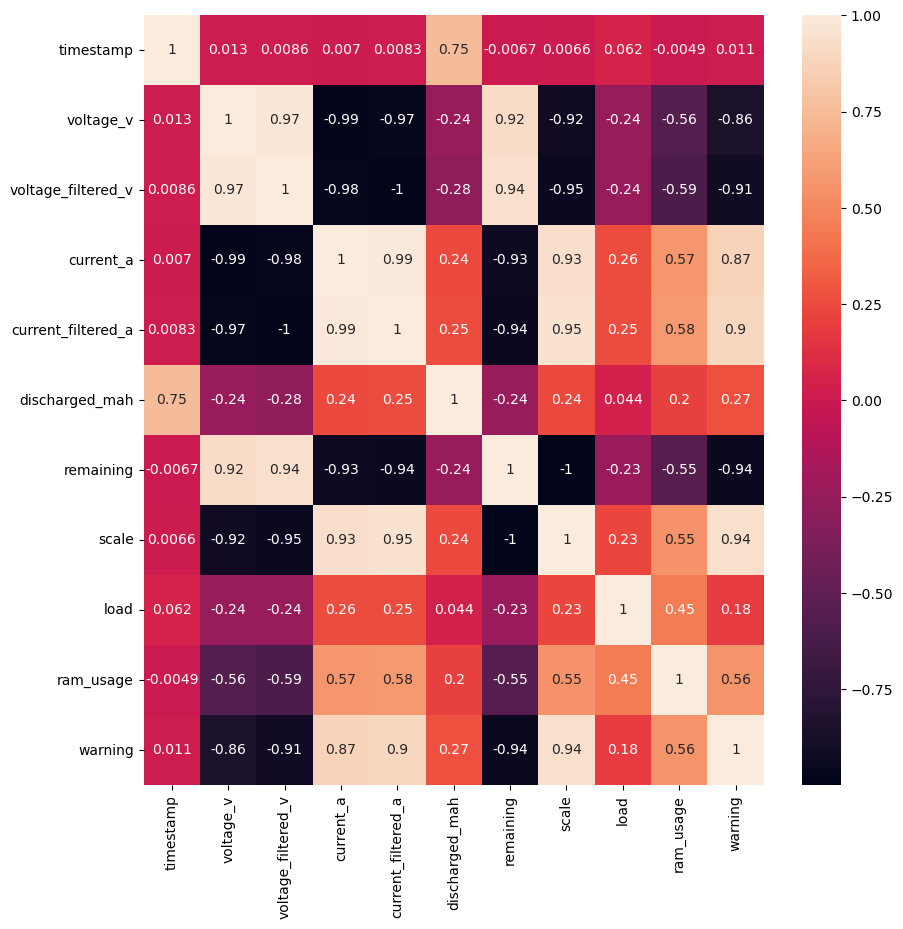

In [ ]:
#Question 2b -
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import r_regression
from sklearn.feature_selection import SelectKBest
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns 
import pandas as pd 
import numpy as np

plt.figure(figsize=(10, 10))
sns.heatmap(drones.corr(), annot=True) #checking for multicolinearity 

#Univariate Selection
select_k_best = SelectKBest(r_regression, k=3)
x_train_k_best = select_k_best.fit_transform(x_train, y_train)
selected_kbest = x.columns[select_k_best.get_support()]
x_train_kbest = x_train[selected_kbest]
x_test_kbest = x_test[selected_kbest]

kbest_data = pd.concat([x_train_kbest, y_train], axis=1)
kbest_data = pd.DataFrame(kbest_data)

#RFE
logreg = LogisticRegression(max_iter= 1000) #to prevent RFE from timing out
rfe = RFE(estimator= logreg, n_features_to_select= 3)
rfe.fit(x_train, y_train)
selected_recursive = x.columns[rfe.support_]
x_train_recursive = x_train[selected_recursive]
x_test_recursive = x_test[selected_recursive]

#output is dataframe with only selected features. Remember to print these
recursive_data = pd.concat([x_train_recursive, y_train], axis=1)
recursive_data = pd.DataFrame(recursive_data)

In [70]:
kbest_data

,current_a,current_filtered_a,scale,warning
4297,19.083600,19.200127,1.157143,3
2528,19.331598,18.745798,1.157143,3
452,19.108398,18.915770,1.157143,3
1478,20.484800,19.543030,1.157143,3
2133,18.364399,18.462875,1.157143,3
...,...,...,...,...
2328,2.256800,2.047221,1.035284,0
3119,17.608000,17.313835,1.157143,3
5210,17.273200,18.472332,1.157143,3
3673,18.277600,18.244839,1.157143,3


In [71]:
recursive_data

,voltage_filtered_v,current_a,remaining,warning
4297,17.003874,19.083600,0.000000,3
2528,17.020683,19.331598,0.000000,3
452,17.118624,19.108398,0.000000,3
1478,16.743979,20.484800,0.000000,3
2133,17.013220,18.364399,0.000000,3
...,...,...,...,...
2328,23.215164,2.256800,0.749037,0
3119,17.571665,17.608000,0.000000,3
5210,16.980722,17.273200,0.000000,3
3673,16.814957,18.277600,0.000000,3


In [72]:
#Question 2c 
import pandas as pd 
binnedkbest = kbest_data.copy()
for col in binnedkbest.columns:
    if col == 'warning':
        continue 
    binnedkbest[col] = pd.cut(binnedkbest[col], bins= 5)

binnedrecursive = recursive_data.copy() #copies made to avoid the data overwriting each other when I bin the data again after removing outliers
for col in binnedrecursive.columns:
    if col == 'warning':
        continue 
    binnedrecursive[col] = pd.cut(binnedrecursive[col], bins= 5)

In [73]:
binnedkbest

,current_a,current_filtered_a,scale,warning
4297,"(17.801, 22.221]","(17.082, 21.309]","(1.129, 1.157]",3
2528,"(17.801, 22.221]","(17.082, 21.309]","(1.129, 1.157]",3
452,"(17.801, 22.221]","(17.082, 21.309]","(1.129, 1.157]",3
1478,"(17.801, 22.221]","(17.082, 21.309]","(1.129, 1.157]",3
2133,"(17.801, 22.221]","(17.082, 21.309]","(1.129, 1.157]",3
...,...,...,...,...
2328,"(0.102, 4.543]","(0.15, 4.399]","(1.018, 1.046]",0
3119,"(13.382, 17.801]","(17.082, 21.309]","(1.129, 1.157]",3
5210,"(13.382, 17.801]","(17.082, 21.309]","(1.129, 1.157]",3
3673,"(17.801, 22.221]","(17.082, 21.309]","(1.129, 1.157]",3


In [74]:
binnedrecursive

,voltage_filtered_v,current_a,remaining,warning
4297,"(16.111, 17.659]","(17.801, 22.221]","(-0.000872, 0.174]",3
2528,"(16.111, 17.659]","(17.801, 22.221]","(-0.000872, 0.174]",3
452,"(16.111, 17.659]","(17.801, 22.221]","(-0.000872, 0.174]",3
1478,"(16.111, 17.659]","(17.801, 22.221]","(-0.000872, 0.174]",3
2133,"(16.111, 17.659]","(17.801, 22.221]","(-0.000872, 0.174]",3
...,...,...,...,...
2328,"(22.279, 23.819]","(0.102, 4.543]","(0.698, 0.872]",0
3119,"(16.111, 17.659]","(13.382, 17.801]","(-0.000872, 0.174]",3
5210,"(16.111, 17.659]","(13.382, 17.801]","(-0.000872, 0.174]",3
3673,"(16.111, 17.659]","(17.801, 22.221]","(-0.000872, 0.174]",3


In [75]:
def outlierbounds(sr):
    quartiles = sr.quantile([0.25, 0.75])
    iqr = quartiles[0.75] - quartiles[0.25]
    lb = quartiles[0.25] - 1.5 * iqr
    ub = quartiles[0.75] + 1.5 * iqr
    return (lb, ub)

def classoutliers(df):
    clean_data = []
    for category in df['warning'].unique(): # loops through each unique class in warningd
        subset = df[df['warning'] == category].copy() #this creates a second dataframe for each unique class
        for col in subset.columns: # loops through the columns selected from feature selection and removes outliers for each feature in each class
            if col == 'warning':
                continue 
            lb, ub = outlierbounds(subset[col])
            subset = subset[(subset[col] >= lb) & (subset[col] <= ub)]
        clean_data.append(subset)
    return pd.concat(clean_data)

In [76]:
kbest_cleaned = classoutliers(kbest_data)
recursive_cleaned = classoutliers(recursive_data)

In [77]:

x_cleanbest = kbest_cleaned.drop(columns=['warning']).copy()
for col in x_cleanbest.columns:
    x_cleanbest[col] = pd.cut(x_cleanbest[col], bins=5, labels=False)
    
x_cleanre = recursive_cleaned.drop(columns=['warning']).copy()
for col in x_cleanre.columns:
    x_cleanre[col] = pd.cut(x_cleanre[col], bins=5, labels=False)


In [78]:
print(x_cleanbest)
print(x_cleanre)

      current_a  current_filtered_a  scale
4297          4                   4      4
2528          4                   4      4
452           4                   4      4
1478          4                   4      4
2133          4                   4      4
...         ...                 ...    ...
2037          2                   2      4
5375          2                   2      4
4173          2                   2      4
2916          2                   2      4
3984          2                   2      4

[3711 rows x 3 columns]
      voltage_filtered_v  current_a  remaining
4297                   0          4          0
2528                   0          4          0
452                    0          4          0
1478                   0          4          0
2133                   0          4          0
...                  ...        ...        ...
2037                   2          2          0
5375                   2          2          0
4173                   2          2 

In [79]:
#Question 2d
#fit for clean data as well 
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import numpy as np

dectree_kbest = DecisionTreeClassifier(max_depth=3)
x_binnedkbest = binnedkbest.drop(columns=['warning'])
for col in x_binnedkbest:
    x_binnedkbest[col] = x_binnedkbest[col].cat.codes
y_binnedkbest = binnedkbest['warning']
dectree_kbest.fit(x_binnedkbest, y_binnedkbest)

DecisionTreeClassifier(max_depth=3)

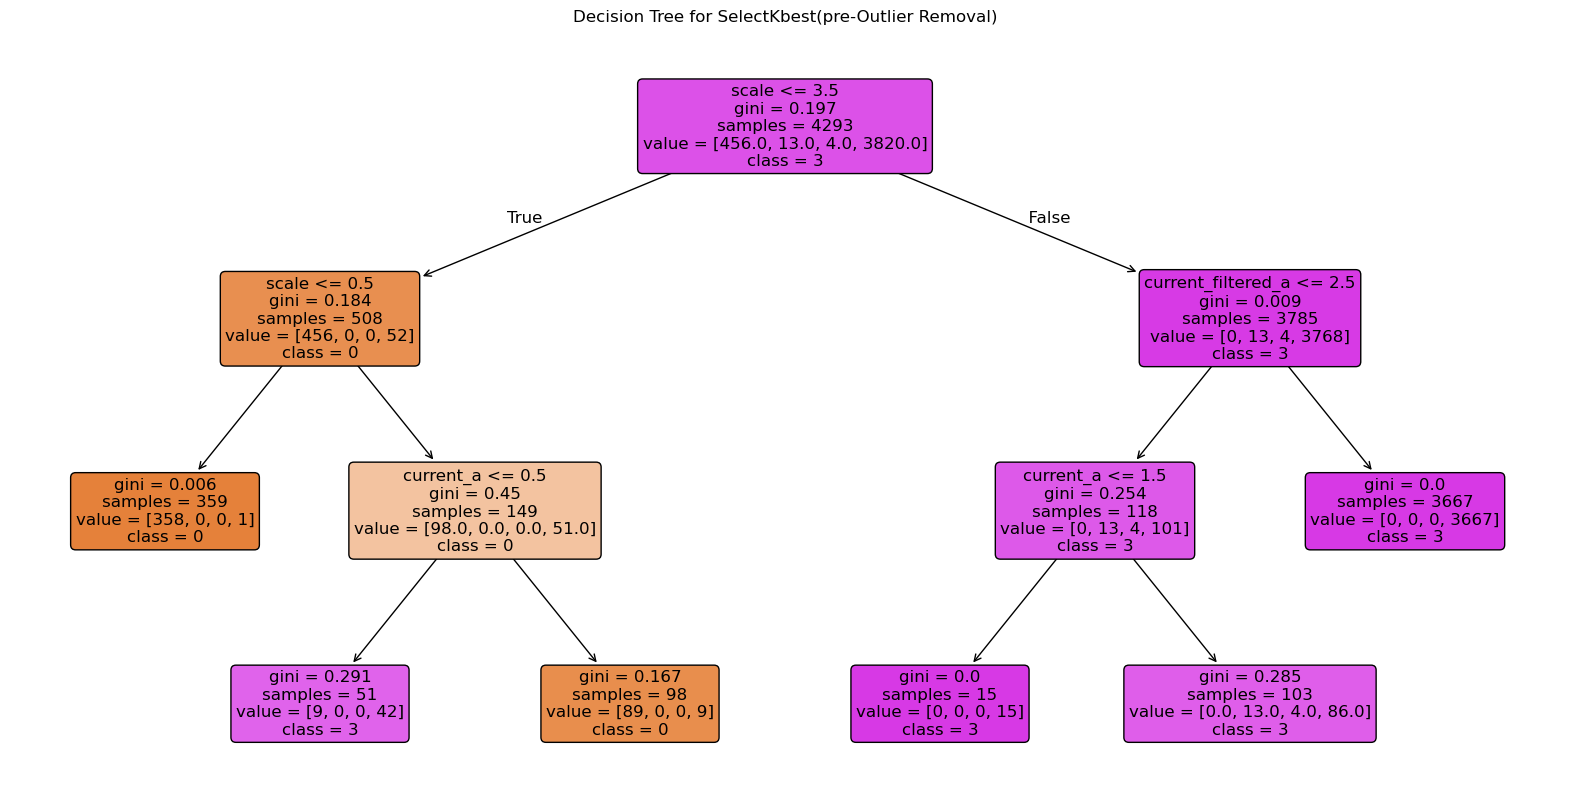

In [80]:
plt.figure(figsize=(20,10))

plot_tree(dectree_kbest, 
          feature_names=selected_kbest.tolist(),  # Shows variable names instead of X[0]
          class_names=['0', '1', '2', '3'], # Map codes to names
          filled=True,         # Colors the nodes based on the majority class
          rounded=True,        # Makes the boxes look nicer
          fontsize=12)         # Adjust text size

plt.title("Decision Tree for SelectKbest(pre-Outlier Removal)")
plt.show()

In [81]:
dectree_recursive = DecisionTreeClassifier(max_depth=3)
x_binnedrecursive = binnedrecursive.drop(columns=['warning'])
for col in x_binnedrecursive:
    x_binnedrecursive[col] = x_binnedrecursive[col].cat.codes
y_binnedrecursive = binnedrecursive['warning']
dectree_recursive.fit(x_binnedrecursive, y_binnedrecursive)

DecisionTreeClassifier(max_depth=3)

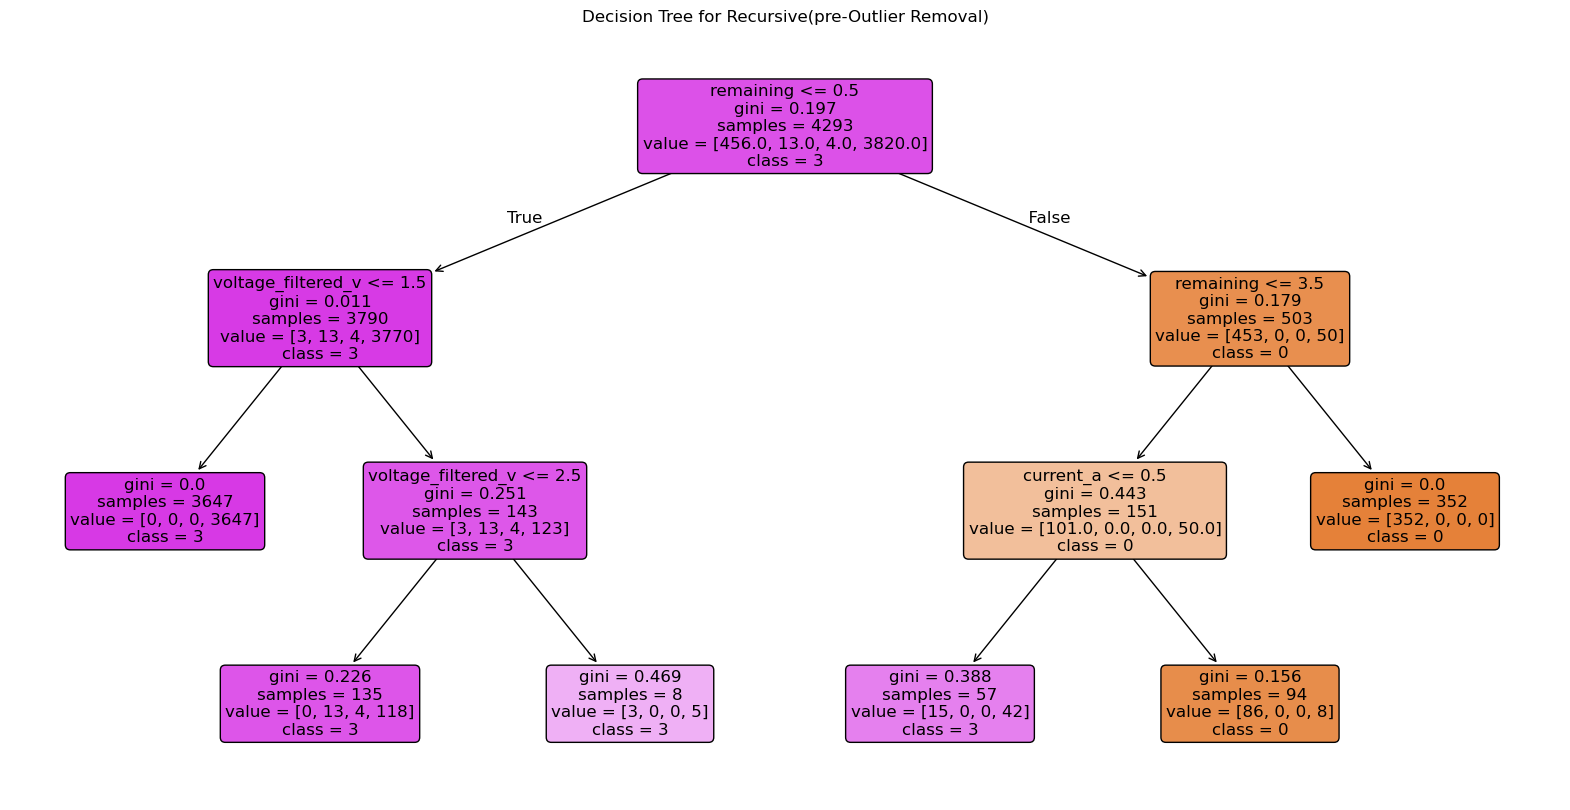

In [82]:
plt.figure(figsize=(20,10))

plot_tree(dectree_recursive, 
          feature_names=selected_recursive.tolist(),  # Shows variable names instead of X[0]
          class_names=['0', '1', '2', '3'], # Map codes to names
          filled=True,         # Colors the nodes based on the majority class
          rounded=True,        # Makes the boxes look nicer
          fontsize=12)         # Adjust text size

plt.title("Decision Tree for Recursive(pre-Outlier Removal)")
plt.show()

In [83]:
dectree_cleanbest = DecisionTreeClassifier(max_depth=3)
y_cleanbest = kbest_cleaned['warning']
y_cleanbest = y_cleanbest.astype('category').cat.codes
dectree_cleanbest.fit(x_cleanbest, y_cleanbest) #cleaning has created different sized data sets so y had to be redefned 

DecisionTreeClassifier(max_depth=3)

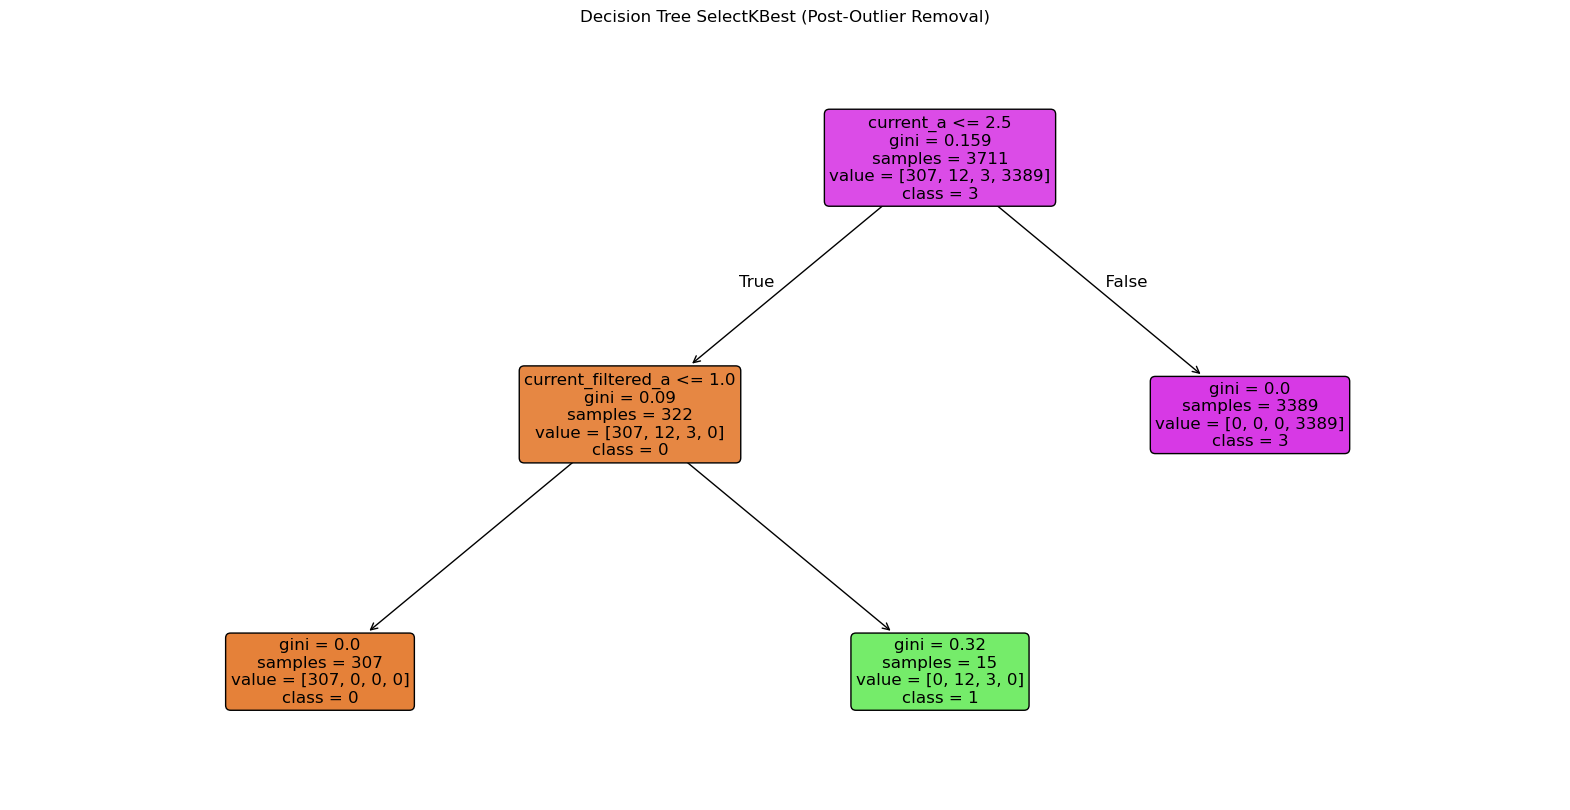

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))

plot_tree(dectree_cleanbest, 
          feature_names=x_cleanbest.columns.tolist(),
          class_names=['0', '1', '2', '3'],
          filled=True,        
          rounded=True,       
          fontsize=12)         

plt.title("Decision Tree SelectKBest (Post-Outlier Removal)")
plt.show()

In [85]:
dectree_cleanre = DecisionTreeClassifier(max_depth=3)
y_cleanre = recursive_cleaned['warning']
y_cleanre = y_cleanre.astype('category').cat.codes
dectree_cleanre.fit(x_cleanre, y_cleanre)

DecisionTreeClassifier(max_depth=3)

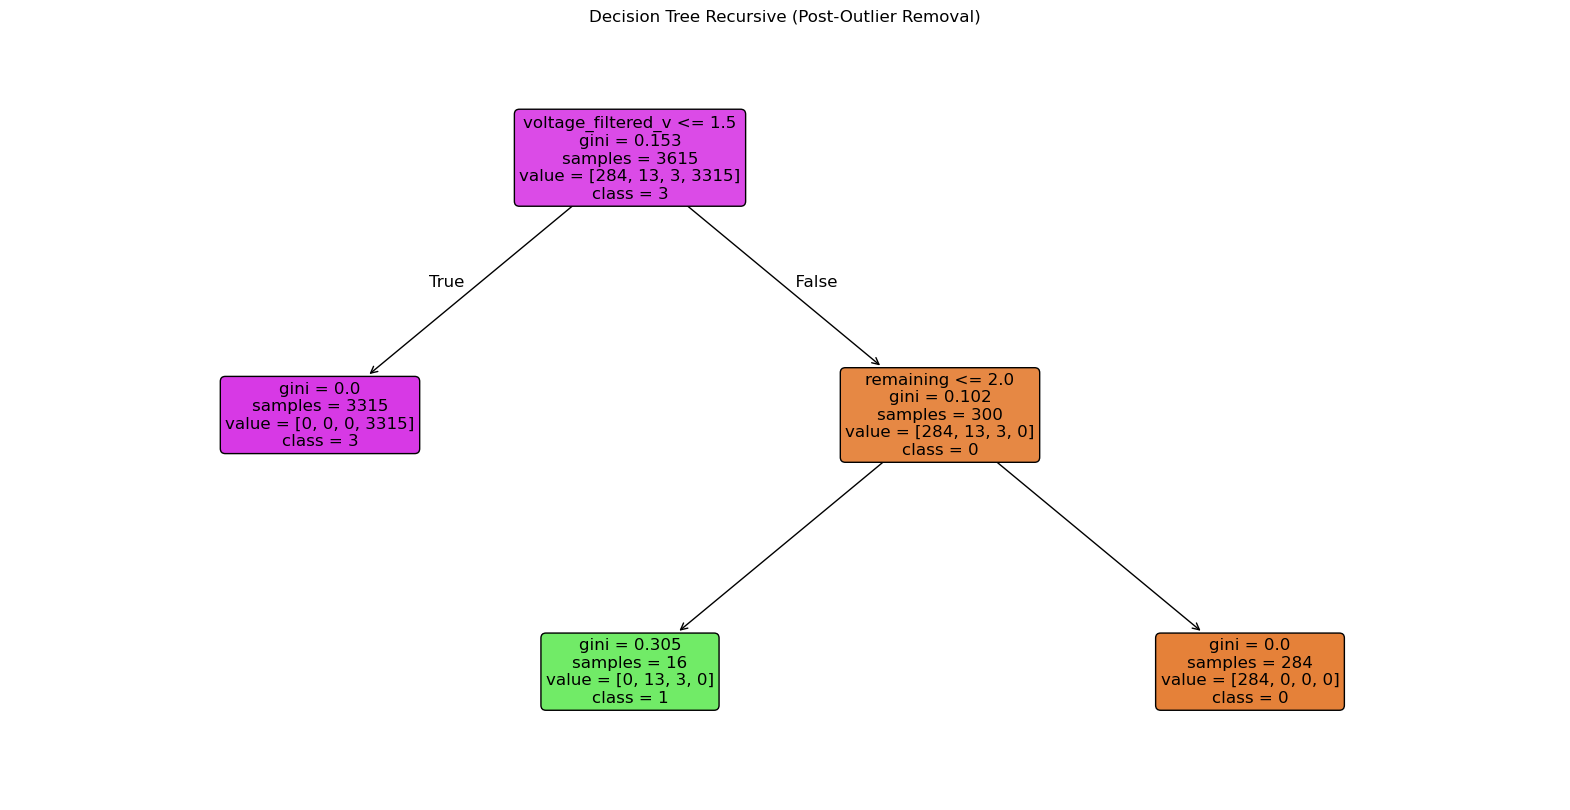

In [ ]:
plt.figure(figsize=(20,10))

plot_tree(dectree_cleanre, 
          feature_names=x_cleanre.columns.tolist(),
          class_names=['0', '1', '2', '3'], 
          filled=True,     
          rounded=True,  
          fontsize=12)    

plt.title("Decision Tree Recursive (Post-Outlier Removal)")
plt.show()

In [87]:
#Question 2e 
x_test_kbest_binned = x_test[selected_kbest].copy()
for col in x_test_kbest_binned.columns:
    train_bins = binnedkbest[col].cat.categories #same boundaries as the bins created for binnedkbest
    x_test_kbest_binned[col] = pd.cut(x_test_kbest_binned[col], 
                               bins = train_bins,
                               include_lowest= True) #to avoid data leakage. Small values captured in the bin 
    x_test_kbest_binned[col] = x_test_kbest_binned[col].cat.codes #this converts the intervals to integers
#removal of outliers changes the training ranges so values in test might fall outside of the boundaries 
y_pred_kbest_binned = dectree_kbest.predict(x_test_kbest_binned)

In [88]:
x_test_recursive = x_test[selected_recursive].copy()
for col in x_test_recursive.columns:
    train_bins = binnedrecursive[col].cat.categories
    x_test_recursive[col] = pd.cut(x_test_recursive[col], 
                                   bins = train_bins, 
                                   include_lowest=True)
    x_test_recursive[col] = x_test_recursive[col].cat.codes
y_pred_re_binned = dectree_recursive.predict(x_test_recursive)

In [89]:
for col in x_cleanbest.columns:
    x_cleanbest[col], bins = pd.cut(x_cleanbest[col], 
                                    bins = 5, 
                                    retbins=True,
                                      labels=False)
    x_test_kbest[col] = pd.cut(x_test_kbest[col], 
                               bins = bins, 
                               labels=False,
                               include_lowest=True)
x_test_cleanbest_binned = x_test_kbest.fillna(4)
y_pred_cleanbest_binned = dectree_cleanbest.predict(x_test_cleanbest_binned)

/var/folders/46/34dm2pn53zb9gx2wyvg_4x2c0000gn/T/ipykernel_75060/1494262281.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_test_kbest[col] = pd.cut(x_test_kbest[col],


In [90]:
for col in x_cleanre.columns:
    x_cleanre[col], bins = pd.cut(x_cleanre[col],
                                   bins = 5, 
                                   retbins = True, 
                                   labels = False)
    x_test_recursive[col] = pd.cut(x_test_recursive[col], 
                            bins = bins, 
                            labels= False, 
                            include_lowest=True)
x_test_cleanre_binned = x_test_recursive.fillna(4)
y_pred_cleanre_binned = dectree_cleanre.predict(x_test_cleanre_binned)

In [91]:
kbest_train_cats = binnedkbest['warning'].astype('category').cat.categories
y_test_kbest_binned = pd.Categorical(y_test, categories=kbest_train_cats)
print(accuracy_score(y_test_kbest_binned, y_pred_kbest_binned))
print(confusion_matrix(y_test_kbest_binned, y_pred_kbest_binned))
print(classification_report(y_test_kbest_binned, y_pred_kbest_binned))

0.1187980433263452
[[ 148    0    0    4]
 [   0    0    0    5]
 [   0    0    0    1]
 [1251    0    0   22]]
              precision    recall  f1-score   support

           0       0.11      0.97      0.19       152
           1       0.00      0.00      0.00         5
           2       0.00      0.00      0.00         1
           3       0.69      0.02      0.03      1273

    accuracy                           0.12      1431
   macro avg       0.20      0.25      0.06      1431
weighted avg       0.62      0.12      0.05      1431



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [92]:
recursive_train_cats = binnedrecursive['warning'].astype('category').cat.categories
y_test_re_binned = pd.Categorical(y_test, categories=recursive_train_cats)
print(accuracy_score(y_test_re_binned, y_pred_re_binned))
print(confusion_matrix(y_test_re_binned, y_pred_re_binned))
print(classification_report(y_test_re_binned, y_pred_re_binned)) 

0.9888190076869322
[[ 145    0    0    7]
 [   0    0    0    5]
 [   0    0    0    1]
 [   3    0    0 1270]]
              precision    recall  f1-score   support

           0       0.98      0.95      0.97       152
           1       0.00      0.00      0.00         5
           2       0.00      0.00      0.00         1
           3       0.99      1.00      0.99      1273

    accuracy                           0.99      1431
   macro avg       0.49      0.49      0.49      1431
weighted avg       0.98      0.99      0.99      1431



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [93]:
y_pred_cleanbest_binned = dectree_cleanbest.predict(x_test_cleanbest_binned)
cleanbest_train_cats = kbest_cleaned['warning'].astype('category').cat.categories
y_test_cleanbest_binned= pd.Categorical(y_test, categories=cleanbest_train_cats).codes
print(accuracy_score(y_test_cleanbest_binned, y_pred_cleanbest_binned))
print(confusion_matrix(y_test_cleanbest_binned, y_pred_cleanbest_binned))
print(classification_report(y_test_cleanbest_binned, y_pred_cleanbest_binned))

0.9503843466107617
[[ 102    3    0   47]
 [   0    0    0    5]
 [   0    0    0    1]
 [   2   13    0 1258]]
              precision    recall  f1-score   support

           0       0.98      0.67      0.80       152
           1       0.00      0.00      0.00         5
           2       0.00      0.00      0.00         1
           3       0.96      0.99      0.97      1273

    accuracy                           0.95      1431
   macro avg       0.49      0.41      0.44      1431
weighted avg       0.96      0.95      0.95      1431



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [94]:
y_pred_cleanre_binned = dectree_cleanre.predict(x_test_cleanre_binned)
cleanre_train_cats = recursive_cleaned['warning'].astype('category').cat.categories
y_test_cleanre_binned = pd.Categorical(y_test, categories=cleanre_train_cats).codes
print(accuracy_score(y_test_cleanre_binned, y_pred_cleanre_binned))
print(confusion_matrix(y_test_cleanre_binned, y_pred_cleanre_binned))
print(classification_report(y_test_cleanre_binned, y_pred_cleanre_binned)) 

0.939203354297694
[[ 121   31    0    0]
 [   0    5    0    0]
 [   0    1    0    0]
 [   2   53    0 1218]]
              precision    recall  f1-score   support

           0       0.98      0.80      0.88       152
           1       0.06      1.00      0.11         5
           2       0.00      0.00      0.00         1
           3       1.00      0.96      0.98      1273

    accuracy                           0.94      1431
   macro avg       0.51      0.69      0.49      1431
weighted avg       0.99      0.94      0.96      1431



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
